In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import ndimage as ndi
from skimage.color import rgb2gray
from skimage.exposure import rescale_intensity
from skimage.filters import sobel, prewitt_h, prewitt_v
from skimage.feature import canny
from skimage.io import imread, imshow
from skimage.measure import label, regionprops
from skimage.segmentation import clear_border, watershed

In [46]:
def show(img):
    plt.figure(figsize = (30, 10), dpi = 150)
    imshow(img)

def get_segmentation(img):
    img_ng = np.copy(img)
    img_ng[:,:,1] = np.zeros([img_ng.shape[0], img_ng.shape[1]]) # Remove all green
    img_grey = rescale_intensity(rgb2gray(img_ng))
    elevation_map = sobel(img_grey)
    markers = np.zeros_like(img_grey)
    markers[img_grey < .001] = 1
    markers[img_grey > .15] = 2
    segmentation = watershed(elevation_map, markers)
    segmentation = ndi.binary_fill_holes(segmentation - 1)
    return segmentation
    
def split_segments(img, segmentation):
    label_image = label(segmentation)
    regions = regionprops(label_image)
    images = []
    for region in regions:
        images.append(img[region.slice])
    return images
    
def split_verify_images(img):
    segmentation = get_segmentation(img)
    return split_segments(img, segmentation)

def get_color_maps(img):
    rgb_maps = [np.copy(img), np.copy(img), np.copy(img)]
    for i in range(3):
        for j in range(3):
            if i != j:
                rgb_maps[i][:,:,j] = 0
    return [rescale_intensity(rgb2gray(color)) for color in rgb_maps]

In [47]:
sample_image = "/Users/joshua/Developer/civetqc/data/raw/INSIGHT/raw/Insight_1001_verify.png"

In [48]:
img = imread(sample_image)[:,:,:3] # Remove alpha channel which is not used

In [41]:
segmentation = get_segmentation(img)

In [49]:
images = split_verify_images(img)

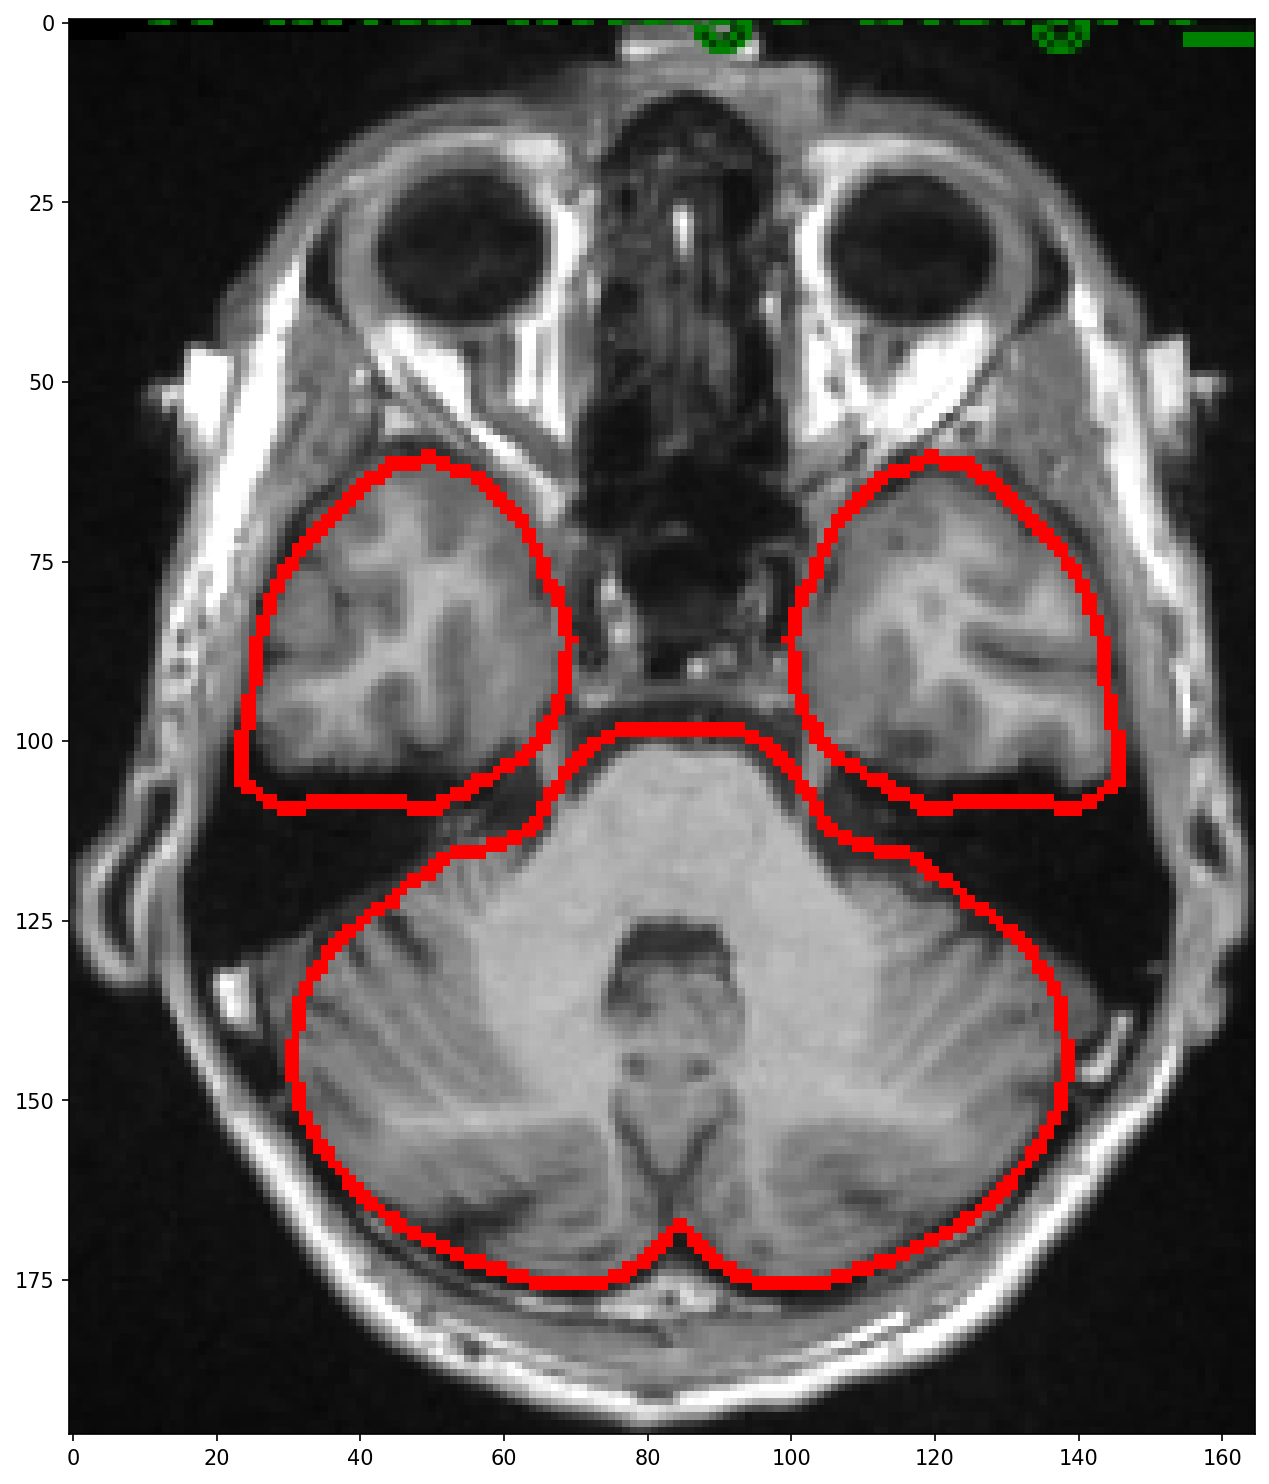

In [50]:
show(images[0])

In [ ]:
red, green, blue = get_color_maps(img)

In [ ]:
elevation_map = sobel(green)

In [ ]:
show(elevation_map)

In [ ]:
def get_verify_images(img):
    
    img_grey = rgb2gray(img)
    img_grey = rescale_intensity(img_grey)
    
    elevation_map = sobel(img_grey)
    markers = np.zeros_like(img_grey)
    markers[img_grey < .001] = 1
    markers[img_grey > .15] = 2
    segmentation = watershed(elevation_map, markers)
    segmentation = ndi.binary_fill_holes(segmentation - 1)
    
    label_image = label(segmentation)
    regions = regionprops(label_image)
    
    images = []
    for region in regions:
        images.append(img[region.slice])
    
    return images

In [ ]:
images = get_verify_images(img)

In [ ]:
test = images[0]

In [ ]:
show(test)

In [ ]:
red = np.copy(test)
blue = np.copy(test)

In [ ]:
red[:,:,1] = 0
red[:,:,2] = 0
blue[:,:,0] = 0
blue[:,:,1] = 0
red = rescale_intensity(rgb2gray(red))
blue = rescale_intensity(rgb2gray(blue))

In [ ]:
show(red)

In [ ]:
elevation_map = sobel(rg)
markers = np.zeros_like(rg)
markers[rg != 1] = 1
markers[rg == 1] = 2
segmentation = watershed(elevation_map, markers)

In [ ]:
show(segmentation)

In [ ]:
test[:,:,2] = np.zeros([test.shape[0], test.shape[1]]) # Remove all green

In [ ]:
show(test)